# <div style="background-color:rgba(255, 255, 255, 0.1); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(255, 255, 255, 1);"> AC Method</span></span></div>

In [5]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Import PHYS231.py and then run the installer function.
import PHYS231
PHYS231.Installer()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys

In [7]:
from IPython.display import HTML, display


def variable_template_builder():
    html_code = """
    <div style="background-color: #1e1e1e; padding: 15px; border-radius: 8px; font-family: sans-serif; max-width: 520px; color: #ffffff; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        <div style="margin-bottom: 10px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Variable Name(s) (comma-separated):</label>
            <input type="text" id="var_names_input" placeholder="e.g. theta_m, I, B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>
        <div style="margin-bottom: 14px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Units / Comment (Optional, comma-separated):</label>
            <input type="text" id="units_comment_input" placeholder="e.g. deg, A, T" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>
        <button id="copy_btn" onclick="copyAndReset()" style="width: 100%; padding: 10px; background-color: #2da44e; color: white; border: none; border-radius: 6px; font-weight: bold; cursor: pointer; transition: background-color 0.2s;">
            Copy Template & Reset
        </button>
    </div>

    <script>
    function copyAndReset() {
        const varInput = document.getElementById('var_names_input');
        const commentInput = document.getElementById('units_comment_input');
        const btn = document.getElementById('copy_btn');
        
        const vars = varInput.value.split(',').map(s => s.trim()).filter(s => s.length > 0);
        const comments = commentInput.value.split(',').map(s => s.trim());
        
        if (vars.length === 0) {
            btn.innerText = 'Please enter at least one variable name!';
            btn.style.backgroundColor = '#d73a49';
            setTimeout(() => { 
                btn.innerText = 'Copy Template & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
            return;
        }
        
        let lines = [];
        vars.forEach((v, idx) => {
            let comment = comments[idx] !== undefined ? comments[idx] : (comments[0] || '');
            let commentStr = comment ? `  # ${comment}` : '';
            lines.push(`${v} = np.array([])${commentStr}`);
            lines.push(`err_${v} = np.full_like(${v}, 0.0)\\n`);
        });
        
        const fullCode = lines.join('\\n').trim();
        
        navigator.clipboard.writeText(fullCode).then(() => {
            btn.innerText = 'Copied to Clipboard & Cleared!';
            btn.style.backgroundColor = '#1f6feb';
            varInput.value = '';
            commentInput.value = '';
            setTimeout(() => { 
                btn.innerText = 'Copy Template & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
        });
    }
    </script>
    """
    display(HTML(html_code))


# Run to render the interactive widget block
variable_template_builder()

In [8]:
from IPython.display import HTML, display


def graph_template_builder():
    html_code = """
    <div style="background-color: #1e1e1e; padding: 18px; border-radius: 8px; font-family: sans-serif; max-width: 540px; color: #ffffff; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        
        <div style="margin-bottom: 12px;">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Graph / Analysis Type:</label>
            <select id="graph_type" onchange="updateFields()" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; font-family: sans-serif;">
                <option value="LinearFit">Linear Fit (PHYS231.LinearFit)</option>
                <option value="Scatter">Scatter Plot (PHYS231.Scatter)</option>
                <option value="PowerLaw">Power Law Fit (PHYS231.PowerLaw)</option>
                <option value="Charging">RC Charging Fit (PHYS231.Charging)</option>
                <option value="Sine">Sine Wave Fit (PHYS231.Sine)</option>
                <option value="Braking">Magnetic Braking Fit (PHYS231.Braking)</option>
                <option value="Statistics">Histogram & Stats (PHYS231.Statistics)</option>
            </select>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 10px;">
            <div id="box_xData">
                <label id="lbl_xData" style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Data Variable:</label>
                <input type="text" id="xData_input" placeholder="e.g. I" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_yData">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Data Variable:</label>
                <input type="text" id="yData_input" placeholder="e.g. B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="margin-bottom: 10px;" id="box_yErrors">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Errors Variable:</label>
            <input type="text" id="yErrors_input" placeholder="e.g. err_B" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 10px;">
            <div>
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Axis Label:</label>
                <input type="text" id="xlabel_input" placeholder="e.g. Current" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_ylabel">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Axis Label:</label>
                <input type="text" id="ylabel_input" placeholder="e.g. Magnetic Field" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-bottom: 12px;">
            <div>
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">X Units:</label>
                <input type="text" id="xUnits_input" placeholder="e.g. A" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
            <div id="box_yUnits">
                <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Y Units:</label>
                <input type="text" id="yUnits_input" placeholder="e.g. mT" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
            </div>
        </div>

        <div style="margin-bottom: 14px; display: none;" id="box_nbins">
            <label style="display: block; font-size: 12px; font-weight: bold; margin-bottom: 4px; color: #cccccc;">Number of Bins:</label>
            <input type="text" id="nbins_input" placeholder="10" value="10" style="width: 100%; padding: 8px; border-radius: 4px; border: 1px solid #444; background: #2d2d2d; color: white; box-sizing: border-box; font-family: monospace;">
        </div>

        <button id="graph_copy_btn" onclick="copyAndResetGraph()" style="width: 100%; padding: 10px; background-color: #2da44e; color: white; border: none; border-radius: 6px; font-weight: bold; cursor: pointer; transition: background-color 0.2s;">
            Copy Graph Code & Reset
        </button>
    </div>

    <script>
    function updateFields() {
        const type = document.getElementById('graph_type').value;
        const isStats = (type === 'Statistics');

        document.getElementById('box_yData').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_yErrors').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_ylabel').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_yUnits').style.display = isStats ? 'none' : 'block';
        document.getElementById('box_nbins').style.display = isStats ? 'block' : 'none';

        document.getElementById('lbl_xData').innerText = isStats ? 'Data Variable:' : 'X Data Variable:';
    }

    function copyAndResetGraph() {
        const type = document.getElementById('graph_type').value;
        const xData = document.getElementById('xData_input').value.trim() || 'x_data';
        const yData = document.getElementById('yData_input').value.trim() || 'y_data';
        const yErrors = document.getElementById('yErrors_input').value.trim() || 'err_y_data';
        const xlabel = document.getElementById('xlabel_input').value.trim();
        const ylabel = document.getElementById('ylabel_input').value.trim();
        const xUnits = document.getElementById('xUnits_input').value.trim();
        const yUnits = document.getElementById('yUnits_input').value.trim();
        const nbins = document.getElementById('nbins_input').value.trim() || '10';

        let code = '';

        if (type === 'LinearFit') {
            code = `slope, intercept, err_slope, err_intercept, fig = PHYS231.LinearFit(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}",\\n    fill=False\\n)`;
        } else if (type === 'Scatter') {
            code = `fig = PHYS231.Scatter(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}",\\n    fill=False,\\n    show=True\\n)`;
        } else if (type === 'PowerLaw') {
            code = `coeff, power, offset, errA, errN, errC, fig = PHYS231.PowerLaw(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Charging') {
            code = `A, tau, errA, errTau, fig = PHYS231.Charging(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Sine') {
            code = `amp, period, phase, errA, errT, errPhi, fig = PHYS231.Sine(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Braking') {
            code = `v_term, tau, err_v, err_tau, fig = PHYS231.Braking(\\n    xData=${xData},\\n    yData=${yData},\\n    yErrors=${yErrors},\\n    xlabel="${xlabel}",\\n    ylabel="${ylabel}",\\n    xUnits="${xUnits}",\\n    yUnits="${yUnits}"\\n)`;
        } else if (type === 'Statistics') {
            code = `counts, centres, mean, std_dev, std_err, fig = PHYS231.Statistics(\\n    data=${xData},\\n    nbins=${nbins},\\n    xlabel="${xlabel}",\\n    xUnits="${xUnits}",\\n    normalized=False\\n)`;
        }

        const btn = document.getElementById('graph_copy_btn');

        navigator.clipboard.writeText(code).then(() => {
            btn.innerText = 'Copied Code to Clipboard & Cleared!';
            btn.style.backgroundColor = '#1f6feb';
            
            // Clear input fields
            document.getElementById('xData_input').value = '';
            document.getElementById('yData_input').value = '';
            document.getElementById('yErrors_input').value = '';
            document.getElementById('xlabel_input').value = '';
            document.getElementById('ylabel_input').value = '';
            document.getElementById('xUnits_input').value = '';
            document.getElementById('yUnits_input').value = '';
            
            setTimeout(() => { 
                btn.innerText = 'Copy Graph Code & Reset'; 
                btn.style.backgroundColor = '#2da44e';
            }, 2000);
        });
    }
    </script>
    """
    display(HTML(html_code))


graph_template_builder()

# How to set the Lock in Amplifier!   

BY ME

### Reference Channel:
Source is set to external or EXT Ref\
TTL from function gen into Ref in on Lock in Amp\
Set Harmonic to 1f same as the function gen\
Press auto phase once it is active

### Input Channel:
Input mode to A\
Set coupling to AC Coupling\
Grounding to float\
Set Line Filters to ON for both the 60 Hz and 120 Hz line filters to block ambient room lighting

### Filter & Time Constant:
Time constant to like 300ms or 1 sec\
Filter Slope (Roll-off) is set to 24 dB/oct (or 4-pole)\
For taking measurments wait a few seconds for V ac to settle

### Sensitivity:
Adjsut Gain so that its like 65% ish full of the scale\
Could overload if too high

Note: Convert to V ac Peak from V ac RMS if current was measured in peak.

In [30]:

I_sol = np.array([0.1, 0.4, 0.7, 1, 0.2, 0.3, 0.5, 0.6, 0.805, 0.898])  # AC Current of solenoid in Amperes Note to Self use RMS or Peak
err_I_sol = np.full_like(I_sol, 0.0005)

freq = 40  # Modulation Frequency in Hz
err_freq = 1


L = 0.15  # Length of sample in meters
err_L = 0.001 

B = (11.1 * I_sol) / 1000  # Magnetic Field Strength in Tesla (converting 11.1 mT/A to T)
err_B = (11.1 * err_I_sol) / 1000

V_dc = 0.081  # DC baseline photodetector voltage at 45 degrees (Volts)  ie 45 degrees from the extinction point.
err_V_dc = 0.0001

V_ac_mV_RMS = np.array([0.4, 1.67, 2.93, 4.18, 0.83, 1.25, 2.08, 2.52, 3.38, 3.76])  # AC signal voltage from Lock-In Amplifier (Volts)
# Labeled as R on Lock in AMp
err_V_ac_mV_RMS = np.full_like(V_ac, 0.05)


# mV to V and RMS to Peak
V_ac = (V_ac_mV_RMS*np.sqrt(2))/1000
err_V_ac = (err_V_ac_mV_RMS*np.sqrt(2))/1000


# Convert to V ac Peak from V ac RMS if current was measured in peak.     DO THIS



# 60 is light




theta_ac_rad = V_ac / (2 * V_dc)# Faraday rotation angle in radians (from Lock-In amplitude: theta_ac = V_ac / (2 * V_dc)) See Derivation!
err_theta_ac_rad = theta_ac_rad * np.sqrt((err_V_ac / V_ac)**2 + (err_V_dc / V_dc)**2)


theta_ac_deg = np.degrees(theta_ac_rad)  # Faraday rotation angle converted to degrees
err_theta_ac_deg = np.degrees(err_theta_ac_rad)

$y = m\,x + b$

This is a **WEIGHTED** fit.

,,Value,Units
slope,$m =$,3.3058+/-0.0065,rad/T
$y$-intercept,$b =$,-0.000114+/-0.000045,rad


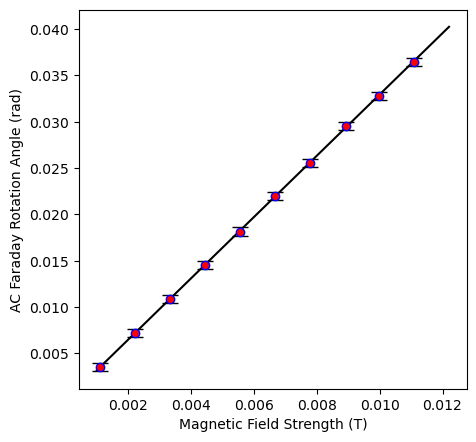

In [31]:
slope, intercept, err_slope, err_intercept, fig = PHYS231.LinearFit(
    xData=B,
    yData=theta_ac_rad,
    yErrors=err_theta_ac_rad,
    xlabel="Magnetic Field Strength",
    ylabel="AC Faraday Rotation Angle",
    xUnits="T",
    yUnits="rad",
    fill=False,
)

In [35]:
V = slope / L  # Units: rad / (T * m)
err_V = V * np.sqrt((err_slope / slope) ** 2 + (err_L / L) ** 2)

print(f"Verdet Constant (V): {V:.2f} +/- {err_V:.2f} rad/(T*m)")

Verdet Constant (V): 22.04 +/- 0.15 rad/(T*m)


### Derivation of Faraday Rotation Angle from AC and DC Voltages for understanding

The relationship $\theta = \frac{V_{\text{ac}}}{2 V_{\text{dc}}}$ is derived by applying **Malus's Law** at a $45^\circ$ bias point, combined with a **small-angle approximation**.

---

#### Step 1: Malus's Law at a $45^\circ$ Bias
The optical power reaching the photodetector follows Malus's Law:

$$I(\phi) = I_{\text{max}} \cos^2(\phi)$$

where $\phi$ is the angle between the linear polarization of light and the transmission axis of the analyzer.

In Method 3 (AC method), the analyzer is set to a baseline bias angle of $45^\circ$ ($\frac{\pi}{4}\text{ rad}$) before applying the alternating magnetic field. When the AC magnetic field fluctuates, it induces a small time-varying Faraday rotation angle $\theta(t)$ on top of that $45^\circ$ offset:

$$\phi(t) = \frac{\pi}{4} + \theta(t)$$

Substituting this into Malus's Law:

$$I(t) = I_{\text{max}} \cos^2\left(\frac{\pi}{4} + \theta(t)\right)$$

---

#### Step 2: Trigonometric Identity
Using the double-angle identity $\cos^2(x) = \frac{1 + \cos(2x)}{2}$:

$$I(t) = \frac{I_{\text{max}}}{2} \left[ 1 + \cos\left(\frac{\pi}{2} + 2\theta(t)\right) \right]$$

Since $\cos\left(\frac{\pi}{2} + x\right) = -\sin(x)$, this simplifies to:

$$I(t) = \frac{I_{\text{max}}}{2} \left[ 1 - \sin(2\theta(t)) \right]$$

---

#### Step 3: Small-Angle Approximation
Because Faraday rotation angles in typical lab setups are extremely small ($\theta \ll 1\text{ rad}$), apply the small-angle approximation $\sin(x) \approx x$, which gives $\sin(2\theta) \approx 2\theta$:

$$I(t) \approx \frac{I_{\text{max}}}{2} \left[ 1 - 2\theta(t) \right] = \frac{I_{\text{max}}}{2} - I_{\text{max}}\theta(t)$$

---

#### Step 4: Separating DC and AC Voltage Components
A photodetector converts light intensity $I(t)$ into a proportional output voltage $V(t) = G \cdot I(t)$, where $G$ represents the detector gain/sensitivity:

$$V(t) = \underbrace{\frac{G \cdot I_{\text{max}}}{2}}_{\text{DC Signal } (V_{\text{dc}})} - \underbrace{G \cdot I_{\text{max}} \cdot \theta(t)}_{\text{AC Signal } (V_{\text{ac}})}$$

Separating these two components yields:

1. **Steady DC Voltage:**
   $$V_{\text{dc}} = \frac{G \cdot I_{\text{max}}}{2} \implies G \cdot I_{\text{max}} = 2 V_{\text{dc}}$$

2. **Oscillating AC Voltage Amplitude:**
   $$V_{\text{ac}} = G \cdot I_{\text{max}} \cdot \theta$$

---

#### Step 5: Solving for the Faraday Rotation Angle ($\theta$)
Substitute $G \cdot I_{\text{max}} = 2 V_{\text{dc}}$ into the AC voltage equation:

$$V_{\text{ac}} = (2 V_{\text{dc}}) \cdot \theta$$

Rearranging to solve for the rotation angle $\theta$ (in radians):

$$\theta = \frac{V_{\text{ac}}}{2 V_{\text{dc}}}$$

